# Staged machine-learning pipeline for maneuver prediction

This notebook implements the four-stage analysis described in Subsection 3.6 to present the analytical workflow, run on the subdataset shared:

- **Setup** section prepares the data and the SMOTE-wrapped model pipeline used by every stage; the analytical procedure then unfolds across Stages 1 to 4.

- **Stage 1 - Performance (Table 5).** Nested cross-validation estimates how well each algorithm predicts the maneuver (Table 5). Hyperparameters were obtained once per algorithm using F1 as the scoring criterion. Within each outer fold, the training split is used for SHAP-based feature ranking, an inner cross-validation within that training split then selects the feature count yielding the highest F1, and the refitted model is evaluated on the held-out outer fold, which never participates in feature selection. 
- **Stage 2 - Optimal feature count (Figure 12).** This stage obtained the optimal feature count *k* using the best-performing tuned algorithm from the first stage. Features were ranked by SHAP importance on the full dataset, and incremental top-*k* subsets were evaluated by cross-validation, selecting the count with the highest mean F1.
- **Stage 3 - Global SHAP analysis (Figure 13).** The best-performing algorithm in Stage 1 is again refit on the full data to produce a global SHAP ranking.
- **Stage 4 - Category contribution (Table 6).** Using *k* and the global ranking obtained, the features retained after multicollinearity pruning are split into eye-tracking and environmental subsets (Appendix 1), whose individual and joint contributions to model performance are compared.

## Setup · Imports and random seed
Load the libraries and fix a global seed (42) so every stochastic step — cross-validation splitting, SMOTE, the hyperparameter search, and the classifiers — is reproducible.

In [1]:
import os, json
import numpy as np
import pandas as pd
from dataclasses import dataclass

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap

import warnings
warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

## Setup · Settings

`DATA_FILE` points at the single file to analyse (features in all columns except the last; label in the last). `ALGOS` lists the algorithms to compare; `OUTER_SPLITS` / `INNER_SPLITS` set the nested-CV folds; `TUNE_MODE="once"` searches hyperparameters one time and then holds them fixed.

In [2]:
DATA_FILE    = "2. Sub_dataset.xlsx"     # <-- the one file to analyse
ALGOS        = ["lr", "xgb", "rf", "dt"]   # run one, or several to compare
TUNE_MODE    = "once"             # "once" | "fixed"

OUTER_SPLITS = 10                 # outer folds: report performance
INNER_SPLITS = 5                  # inner folds: choose the feature count
POS_LABEL    = 1                  # the positive class (set to your steering code)
N_ITER_SEARCH = 60                # hyperparameter-search iterations (XGB / RF)
TUNE_CV       = 5                 # CV folds used inside the one-time search

## Setup · Load the dataset
Read the file into features `X` and label `y`, and print the shape and class balance to confirm the right file loaded. 

In [3]:
def load_xy(path, label_col=-1):
    df = pd.read_excel(path) if str(path).endswith((".xlsx", ".xls")) else pd.read_csv(path)
    y = df.iloc[:, label_col].copy()
    X = df.drop(df.columns[label_col], axis=1).copy()
    return X.reset_index(drop=True), y.reset_index(drop=True)

if os.path.exists(DATA_FILE):
    X, y = load_xy(DATA_FILE)
    print(f"loaded {DATA_FILE}  features={X.shape[1]}  rows={X.shape[0]}  "
          f"class balance={dict(y.value_counts())}")
else:
    from sklearn.datasets import make_classification
    Xa, ya = make_classification(n_samples=200, n_features=14, n_informative=6,
                                 n_redundant=3, weights=[0.78, 0.22], random_state=0)
    X = pd.DataFrame(Xa, columns=[f"feat_{i}" for i in range(14)]); y = pd.Series(ya)
    print(f"!! {DATA_FILE} not found -> SYNTHETIC data  features={X.shape[1]}  rows={X.shape[0]}")

loaded 2. Sub_dataset.xlsx  features=44  rows=199  class balance={0: 143, 1: 56}


## Setup · Resampling pipeline (SMOTE confined to training)
Each algorithm is wrapped as an imbalanced-learn pipeline `[scaler?] -> SMOTE -> classifier`. Because SMOTE is a pipeline step, it resamples only the training portion of whatever split the pipeline is fitted on and is skipped at prediction time, so no synthetic sample ever reaches an evaluation fold. Logistic regression is scaled first; the tree models are not. `params` injects tuned hyperparameters. This pipeline is the model definition used by every stage.

In [4]:
def make_estimator(algo, seed=SEED, params=None):
    algo = algo.lower(); params = params or {}
    if algo == "lr":
        clf = LogisticRegression(max_iter=2000, random_state=seed, **params)
        steps = [("scaler", StandardScaler()), ("smote", SMOTE(random_state=seed)), ("clf", clf)]
    elif algo == "rf":
        clf = RandomForestClassifier(random_state=seed, **params)
        steps = [("smote", SMOTE(random_state=seed)), ("clf", clf)]
    elif algo == "dt":
        clf = DecisionTreeClassifier(random_state=seed, **params)
        steps = [("smote", SMOTE(random_state=seed)), ("clf", clf)]
    elif algo == "xgb":
        d = dict(objective="binary:logistic", eval_metric="logloss",
                 random_state=seed, n_estimators=100, verbosity=0)
        d.update(params)
        steps = [("smote", SMOTE(random_state=seed)), ("clf", XGBClassifier(**d))]
    else:
        raise ValueError(algo)
    return ImbPipeline(steps)

def _is_tree(algo):
    return algo.lower() in ("rf", "dt", "xgb")

## Stage 1 - Overall performance via nested cross-validation (Table 5)

Nested cross-validation estimates how well each algorithm predicts the maneuver (Table 5). Hyperparameters were obtained once per algorithm using F1 as the scoring criterion. Within each outer fold, the training split is used for SHAP-based feature ranking, an inner cross-validation within that training split then selects the feature count yielding the highest F1, and the refitted model is evaluated on the held-out outer fold, which never participates in feature selection. 

### Stage 1 · One-time hyperparameter search
For each algorithm a single search is run once on the file, and the chosen setting is then held fixed for every stage. The search resamples inside its own CV folds (SMOTE is part of the pipeline) and scores all four algorithms by **F1**, so they are tuned on a comparable, imbalance-appropriate basis. The grids are the standard ranges for each model.

In [5]:
GRIDS = {
    "xgb": dict(kind="random", grid={
        "clf__n_estimators": [80, 90, 100, 200, 300],
        "clf__max_depth": [3, 5, 7, 10, 15],
        "clf__min_child_weight": [1, 3, 5],
        "clf__gamma": [0, 0.1, 0.2, 0.3, 0.4],
        "clf__subsample": [0.7, 0.8, 0.9],
        "clf__colsample_bytree": [0.7, 0.8, 0.9],
        "clf__learning_rate": [0.01, 0.05, 0.1, 0.2]}),
    "rf": dict(kind="random", grid={
        "clf__n_estimators": [80, 90, 100, 200, 300],
        "clf__max_depth": [None, 60, 70, 30, 40, 50],
        "clf__min_samples_split": [2, 5, 10],
        "clf__min_samples_leaf": [1, 2, 4],
        "clf__bootstrap": [True, False],
        "clf__criterion": ["gini", "entropy"]}),
    "dt": dict(kind="grid", grid={
        "clf__criterion": ["gini", "entropy"],
        "clf__max_depth": [None, 5, 10, 20],
        "clf__min_samples_split": [2, 5, 10],
        "clf__min_samples_leaf": [1, 2, 4]}),
    "lr": dict(kind="grid", grid={
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__penalty": ["l2"],
        "clf__solver": ["lbfgs", "liblinear"]}),
}

def tune_once(algo, X, y, seed=SEED):
    spec = GRIDS[algo]
    base = make_estimator(algo, seed=seed)
    cv = StratifiedKFold(n_splits=TUNE_CV, shuffle=True, random_state=seed)
    if spec["kind"] == "random":
        search = RandomizedSearchCV(base, spec["grid"], n_iter=N_ITER_SEARCH, cv=cv,
                                    scoring="f1", random_state=seed, n_jobs=-1)
    else:
        search = GridSearchCV(base, spec["grid"], cv=cv, scoring="f1", n_jobs=-1)
    search.fit(X, y)
    best = {k.replace("clf__", ""): v for k, v in search.best_params_.items()}
    return best, search.best_score_

def get_params(algo, X, y):
    if TUNE_MODE == "fixed":
        return {}
    best, score = tune_once(algo, X, y)
    print(f"    tuned {algo.upper():>3}: F1(search)={score:.3f}  params={best}")
    return best

### Stage 1 · SHAP feature ranking (training rows only)
Rank features by mean |SHAP| on the outer-training split of each outer fold, evaluated on the original, un-resampled training rows. The estimator (the SMOTE-wrapped pipeline) uses the hyperparameters from the one-time search above.

In [6]:
def _shap_mean_abs(sv):
    if isinstance(sv, list):
        a = sv[1] if len(sv) > 1 else sv[0]
    elif np.ndim(sv) == 3:
        a = sv[:, :, 1]
    else:
        a = sv
    return np.abs(a).mean(axis=0)

def shap_rank_features(algo, X_train, y_train, params, seed=SEED):
    pipe = make_estimator(algo, seed=seed, params=params).fit(X_train, y_train)
    clf = pipe.named_steps["clf"]
    if _is_tree(algo):
        sv = shap.TreeExplainer(clf).shap_values(X_train)
    else:
        Xs = pipe.named_steps["scaler"].transform(X_train)
        sv = shap.LinearExplainer(clf, shap.maskers.Independent(Xs)).shap_values(Xs)
    order = np.argsort(_shap_mean_abs(sv))[::-1]
    return [X_train.columns[i] for i in order]

### Stage 1 · Feature-count selection (inner CV)
Decide how many features *k* to keep by an inner cross-validation on the outer-training split. Each candidate *k* (the top-*k* of the ranking) is fit on the inner-training rows and scored by F1, and the k with the best mean F1 is selected, the smallest *k* winning on ties for a simpler model.

In [7]:
def select_k_inner(algo, X_tr, y_tr, ranked, params, inner_splits=INNER_SPLITS,
                   seed=SEED, pos_label=POS_LABEL):
    inner = StratifiedKFold(n_splits=inner_splits, shuffle=True, random_state=seed)
    curve = {}
    for k in range(1, len(ranked) + 1):
        Xk = X_tr[ranked[:k]]; f1s = []
        for tr, va in inner.split(Xk, y_tr):
            est = make_estimator(algo, seed=seed, params=params).fit(Xk.iloc[tr], y_tr.iloc[tr])
            pred = est.predict(Xk.iloc[va])
            f1s.append(f1_score(y_tr.iloc[va], pred, pos_label=pos_label, zero_division=0))
        curve[k] = float(np.mean(f1s))
    best = max(curve.values())
    k_star = min(k for k, v in curve.items() if np.isclose(v, best))
    return k_star, curve

### Stage 1 · Performance estimate (outer CV)
The outer loop assembles the three routines above. Inside each outer fold, the SHAP ranking is computed on the outer-training split, the feature count *k* is chosen by an inner cross-validation within that split, and the model is then refit on the full outer-training split with the selected features and scored on the outer-test fold. Averaging across the outer folds gives the mean ± std for Accuracy, Precision, Recall, and F1. 

In [8]:
@dataclass
class NestedCVResult:
    summary: pd.DataFrame
    per_fold: pd.DataFrame
    algo: str
    params: dict

def nested_cv_performance(X, y, algo="rf", params=None,
                          outer_splits=OUTER_SPLITS, inner_splits=INNER_SPLITS,
                          seed=SEED, pos_label=POS_LABEL, verbose=True):
    X = X.reset_index(drop=True); y = y.reset_index(drop=True)
    params = {} if params is None else params
    outer = StratifiedKFold(n_splits=outer_splits, shuffle=True, random_state=seed)
    rows = []
    for i, (tr, te) in enumerate(outer.split(X, y), 1):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]
        ranked = shap_rank_features(algo, X_tr, y_tr, params, seed)
        k_star, _ = select_k_inner(algo, X_tr, y_tr, ranked, params, inner_splits, seed, pos_label)
        sel = ranked[:k_star]
        est = make_estimator(algo, seed=seed, params=params).fit(X_tr[sel], y_tr)
        pred = est.predict(X_te[sel])
        rows.append(dict(
            fold=i, k=k_star,
            Accuracy=accuracy_score(y_te, pred),
            Precision=precision_score(y_te, pred, pos_label=pos_label, zero_division=0),
            Recall=recall_score(y_te, pred, pos_label=pos_label, zero_division=0),
            F1=f1_score(y_te, pred, pos_label=pos_label, zero_division=0)))
        if verbose:
            r = rows[-1]
            print(f"  [fold {i:>2}] k={k_star:>2}  Acc={r['Accuracy']:.3f}  "
                  f"Prec={r['Precision']:.3f}  Rec={r['Recall']:.3f}  F1={r['F1']:.3f}")
    per_fold = pd.DataFrame(rows)
    metrics = ["Accuracy", "Precision", "Recall", "F1"]
    summary = pd.DataFrame({"metric": metrics,
                            "mean": [per_fold[m].mean() for m in metrics],
                            "std":  [per_fold[m].std(ddof=0) for m in metrics]})
    return NestedCVResult(summary, per_fold, algo, params)

### Stage 1 · Run on the loaded file
Runs the procedure for every algorithm in `ALGOS` and marks the highest mean F1 (Table 5). The Stage-1 winner is stored as `best_algo` and the tuned settings as `tuned_params`, both reused by the later stages.

In [9]:
records = []
tuned_params = {}          # keep the tuned settings to reuse in Stage 2
for algo in ALGOS:
    print(f"== {algo.upper()} ==")
    params = get_params(algo, X, y)
    tuned_params[algo] = params
    res = nested_cv_performance(X, y, algo=algo, params=params, verbose=True)
    s = res.summary.set_index("metric")["mean"]
    records.append({
        "Algorithm": algo.upper(),
        "Accuracy": f"{s['Accuracy']*100:.2f}%",
        "Precision": f"{s['Precision']*100:.2f}%",
        "Recall": f"{s['Recall']*100:.2f}%",
        "F1": f"{s['F1']*100:.2f}%",
        "F1_num": s["F1"],
    })

results = pd.DataFrame(records)
results["best"] = ""
best_idx = results["F1_num"].idxmax()
results.loc[best_idx, "best"] = "*"

# Stage-1 best performer (highest mean F1) -> carried into Stage 2 as the default ALGO_FOR_K.
best_algo = results.loc[best_idx, "Algorithm"].lower()
print(f"\nStage-1 best by mean F1: {results.loc[best_idx, 'Algorithm']} "
      f"(F1={results.loc[best_idx, 'F1']})  ->  default ALGO_FOR_K = '{best_algo}'")

results.drop(columns=["F1_num"])

== LR ==
    tuned  LR: F1(search)=0.811  params={'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
  [fold  1] k=21  Acc=0.900  Prec=0.800  Rec=0.800  F1=0.800
  [fold  2] k=13  Acc=0.800  Prec=0.571  Rec=0.800  F1=0.667
  [fold  3] k=16  Acc=0.800  Prec=0.571  Rec=0.800  F1=0.667
  [fold  4] k=19  Acc=1.000  Prec=1.000  Rec=1.000  F1=1.000
  [fold  5] k=14  Acc=0.900  Prec=0.750  Rec=1.000  F1=0.857
  [fold  6] k=12  Acc=0.750  Prec=0.556  Rec=0.833  F1=0.667
  [fold  7] k=11  Acc=0.900  Prec=0.833  Rec=0.833  F1=0.833
  [fold  8] k=14  Acc=0.900  Prec=0.833  Rec=0.833  F1=0.833
  [fold  9] k=34  Acc=0.850  Prec=0.800  Rec=0.667  F1=0.727
  [fold 10] k= 8  Acc=0.789  Prec=0.571  Rec=0.800  F1=0.667
== XGB ==
    tuned XGB: F1(search)=0.822  params={'subsample': 0.8, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.7}
  [fold  1] k=43  Acc=0.950  Prec=1.000  Rec=0.800  F1=0.889
  [fold  2] k=11  Acc=0.750  Prec=0.500  

,Algorithm,Accuracy,Precision,Recall,F1,best
0,LR,85.89%,72.87%,83.67%,77.18%,
1,XGB,89.45%,83.12%,78.00%,79.80%,*
2,RF,87.95%,83.38%,73.00%,76.61%,
3,DT,84.89%,74.29%,74.33%,73.22%,


## Stage 2 - Optimal feature count (Figure 12)

Stage 2 obtains the optimal feature count k using the best-performing tuned algorithm from Stage 1. A model is first fit once on the full dataset to produce a SHAP ranking; this model only guides the feature order and is then discarded. Following that ranking, each top-k subset is trained and evaluated separately by cross-validation, and the count with the highest mean F1 is selected. This stage serves only to report one representative feature count for Stage 4, where the individual and joint contributions of the feature categories are examined; it is not a claim about model performance.

By default `ALGO_FOR_K` is left as `None` and resolves automatically to the Stage-1 best performer (highest mean F1); set it manually (e.g. `"rf"`) to override for a given context. 

In [10]:
# Algorithm to report the optimal k for.
#   None                       -> use the Stage-1 best performer (highest mean F1) automatically.
#   "lr" / "rf" / "dt" / "xgb" -> override manually for this context.
ALGO_FOR_K  = None
K_CV_SPLITS = 5        # folds used to average F1 at each k

# resolve the algorithm: manual override if given, otherwise the Stage-1 winner
if ALGO_FOR_K is None:
    if "best_algo" in dir() and best_algo:
        ALGO_FOR_K = best_algo
        print(f"ALGO_FOR_K not set -> using Stage-1 best performer: {ALGO_FOR_K.upper()}")
    else:
        raise ValueError("Run Stage 1 first, or set ALGO_FOR_K manually (e.g. 'rf').")
else:
    print(f"ALGO_FOR_K set manually: {ALGO_FOR_K.upper()}")

# reuse the hyperparameters tuned in Stage 1 (re-tune only if not available)
if "tuned_params" not in dir():
    tuned_params = {}
params_k = tuned_params[ALGO_FOR_K] if ALGO_FOR_K in tuned_params else get_params(ALGO_FOR_K, X, y)

# 1) rank every feature on the full data
ranked_full = shap_rank_features(ALGO_FOR_K, X, y, params_k)

# 2) sweep k: mean F1 over K_CV_SPLITS folds for each top-k subset; pick the best (smallest on ties)
k_star, curve = select_k_inner(ALGO_FOR_K, X, y, ranked_full, params_k, inner_splits=K_CV_SPLITS)
selected_features = ranked_full[:k_star]

print(f"optimal k = {k_star}   (mean F1 at k* = {curve[k_star]:.3f})")
print("selected features:", list(selected_features))
pd.DataFrame({"k": list(curve), "mean_F1": [curve[k] for k in curve]})

ALGO_FOR_K not set -> using Stage-1 best performer: XGB
optimal k = 17   (mean F1 at k* = 0.832)
selected features: ['Risk dynamics', 'Traffic density', 'Ave of pupil diameter variation', 'Escape path available', 'Risk position', 'Std of pupil diameter', 'Observation on adjacent vehicles', 'Roll', 'Std of pupil diameter variation', 'The remaining TTC', 'Ave of fixation duration', 'Yaw', 'Fixation density (Rightside mirror)', 'Ave of fixation duration (Windshield)', 'Max of fixation duration', 'Ave of blink duration', 'Saccade density']


,k,mean_F1
0,1,0.663389
1,2,0.686893
2,3,0.706214
3,4,0.773810
4,5,0.758903
5,6,0.784615
6,7,0.819426
7,8,0.746954
8,9,0.767002
9,10,0.772838


### Stage 2 · Inspect the k curve (Figure 12)
Mean F1 against the number of features, with the chosen `k` marked.

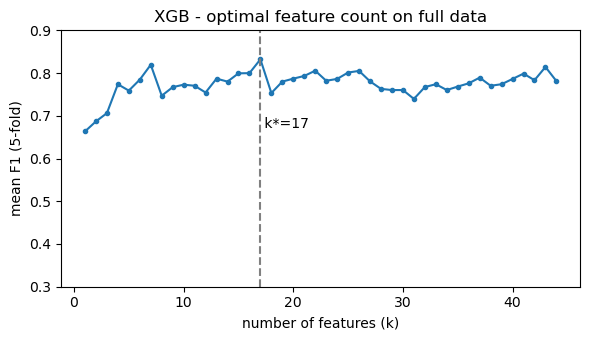

In [11]:
import matplotlib.pyplot as plt
ks = list(curve); vals = [curve[k] for k in ks]
plt.figure(figsize=(6, 3.5))
plt.plot(ks, vals, marker="o", markersize=3)
plt.axvline(k_star, ls="--", color="gray")
plt.ylim(0.3, 0.9)
plt.text(k_star, min(vals), f" k*={k_star}", va="bottom")
plt.xlabel("number of features (k)"); plt.ylabel("mean F1 (5-fold)")
plt.title(f"{ALGO_FOR_K.upper()} - optimal feature count on full data")
plt.tight_layout(); plt.show()

## Stage 3 - Global SHAP analysis (Figure 13)

To interpret what the model learned across the whole dataset, the Stage-1 best algorithm (with its tuned hyperparameters) is refit on the full data, and SHAP is computed on the un-resampled rows to give a global feature-importance ranking (Figure 13). The results reported here provide an interpretation of the behavioural patterns and inform the feature grouping examined in Stage 4, where the individual and joint contributions of the feature categories are assessed.

In [12]:
SHAP_FEATURES = "all"     # "all" = every feature; "topk" = the Stage-2 selected_features

def global_shap(algo, X, y, params, feature_cols=None):
    X_use = X if feature_cols is None else X[list(feature_cols)]
    pipe = make_estimator(algo, seed=SEED, params=params).fit(X_use, y)
    clf = pipe.named_steps["clf"]
    if _is_tree(algo):
        sv = shap.TreeExplainer(clf).shap_values(X_use)
    else:
        Xs = pipe.named_steps["scaler"].transform(X_use)
        sv = shap.LinearExplainer(clf, shap.maskers.Independent(Xs)).shap_values(Xs)
    if isinstance(sv, list):
        sv = sv[1] if len(sv) > 1 else sv[0]
    elif np.ndim(sv) == 3:
        sv = sv[:, :, 1]
    importance = np.abs(sv).mean(axis=0)
    ranking = (pd.DataFrame({"feature": X_use.columns, "mean_abs_shap": importance})
                 .sort_values("mean_abs_shap", ascending=False).reset_index(drop=True))
    return ranking, sv, X_use

cols = None if SHAP_FEATURES == "all" else selected_features
shap_ranking, shap_vals, X_shap = global_shap(ALGO_FOR_K, X, y, params_k, feature_cols=cols)
print(f"global SHAP ranking ({ALGO_FOR_K.upper()}, {SHAP_FEATURES} features):")
shap_ranking

global SHAP ranking (XGB, all features):


,feature,mean_abs_shap
0,Risk dynamics,1.247518
1,Traffic density,0.561636
2,Ave of pupil diameter variation,0.513845
3,Escape path available,0.425117
4,Risk position,0.304795
5,Std of pupil diameter,0.270785
6,Observation on adjacent vehicles,0.261517
7,Roll,0.223569
8,Std of pupil diameter variation,0.143604
9,The remaining TTC,0.136301


### Stage 3 · Figure 13 - global SHAP

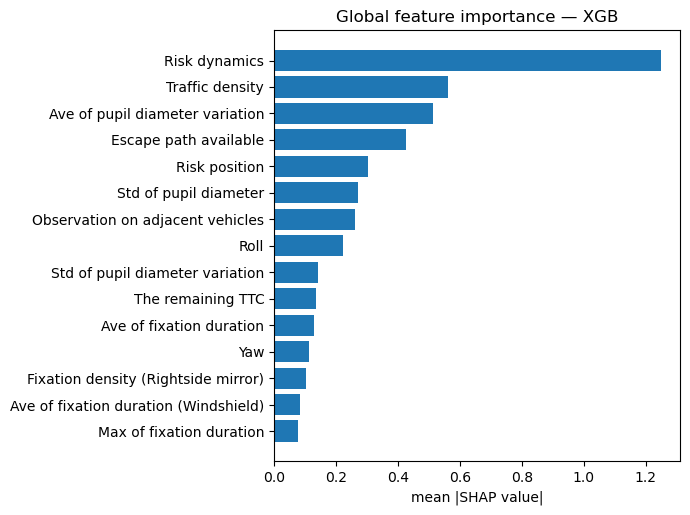

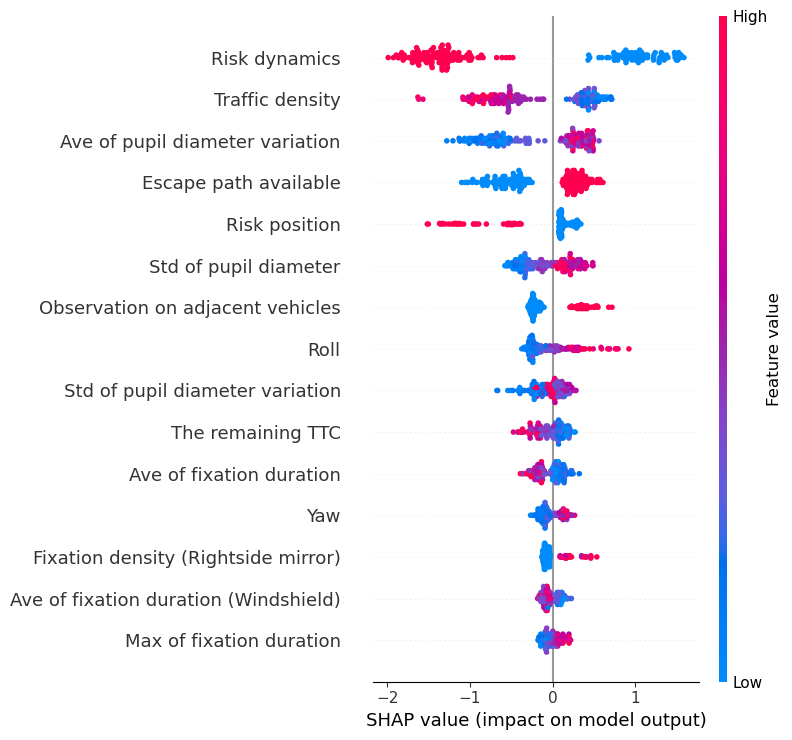

In [13]:
import matplotlib.pyplot as plt

# (a) bar of mean |SHAP| (robust ranking view)
top = shap_ranking.head(15).iloc[::-1]
plt.figure(figsize=(7, max(3, 0.35*len(top))))
plt.barh(top["feature"], top["mean_abs_shap"])
plt.xlabel("mean |SHAP value|"); plt.title(f"Global feature importance — {ALGO_FOR_K.upper()}")
plt.tight_layout(); plt.show()

# (b) beeswarm summary (skipped quietly if the SHAP version/shape doesn't support it)
try:
    shap.summary_plot(shap_vals, X_shap, show=True, max_display=15)
except Exception as e:
    print("beeswarm summary skipped:", e)

## Stage 4 - Feature-category contributions (Table 6, Appendix 1)

Stage 4 compares how much each feature source contributes. Starting from the Stage-2 top-*k* features, a multicollinearity check removes the less important feature of any pair with |r| > 0.7, processing features from most to least important so the stronger feature of each correlated pair is retained (correlation heatmap in Appendix 1). The retained features are split into an eye-tracking subset and an environmental subset, and the Stage-1 best algorithm is evaluated by 10-fold cross-validation (SMOTE inside each fold) on three feature sets - **All**, **Environment** only, and **Eye-tracking** only.Because the top-*k* features were chosen on the full data, these scores are a relative comparison between the categories, not independent absolute performance.

In [14]:
# Feature category membership.  Eye-tracking / physiological vs environment / situational.
EYE_FEATURES = [
    "Fixation density", "Ave of fixation duration", "Max of fixation duration",
    "Saccade density", "Ave of saccade movement", "Ave of saccade velocity", "Ave of saccade acceleration",
    "Ave of pupil diameter", "Std of pupil diameter", "Ave of pupil diameter variation", "Std of pupil diameter variation",
    "Blink density", "Ave of blink duration", "Std of blink duration",
    "Pitch", "Yaw", "Roll",
    "Fixation density (Dashboard)", "Ave of fixation duration (Dashboard)", "Max of fixation duration (Dashboard)",
    "Fixation density (Navigation)", "Ave of fixation duration (Navigation)", "Max of fixation duration (Navigation)",
    "Fixation density (Rearview mirror)", "Ave of fixation duration (Rearview mirror)", "Max of fixation duration (Rearview mirror)",
    "Fixation density (Windshield)", "Ave of fixation duration (Windshield)", "Max of fixation duration (Windshield)",
    "Fixation density (Rightside mirror)", "Ave of fixation duration (Rightside mirror)", "Max of fixation duration (Rightside mirror)",
    "Fixation density (Leftside mirror)", "Ave of fixation duration (Leftside mirror)", "Max of fixation duration (Leftside mirror)",
    "Observation on escape path", "Observation on adjacent vehicles",
    "Driving objective",   # grouped with eye-tracking by author decision (stated in the text)
]
ENV_FEATURES = ["Lane number", "Risk position", "Risk dynamics", "The remaining TTC", "Traffic density", "Escape path available"]

# whitespace-tolerant matching, so stray spaces in the data headers or lists do not cause silent misses
_norm = lambda s: str(s).strip()
_eye_norm = {_norm(f) for f in EYE_FEATURES}
_env_norm = {_norm(f) for f in ENV_FEATURES}

eye_found = [c for c in X.columns if _norm(c) in _eye_norm]
env_found = [c for c in X.columns if _norm(c) in _env_norm]
unlisted  = [c for c in X.columns if _norm(c) not in _eye_norm and _norm(c) not in _env_norm]

# fallback so the synthetic demo still runs when the real columns are absent
if not eye_found and not env_found and all(str(c).startswith("feat_") for c in X.columns):
    EYE_FEATURES = [c for i, c in enumerate(X.columns) if i % 2 == 1]
    ENV_FEATURES = [c for i, c in enumerate(X.columns) if i % 2 == 0]
    _eye_norm = {_norm(f) for f in EYE_FEATURES}
    _env_norm = {_norm(f) for f in ENV_FEATURES}
    print("(demo: synthetic columns split by parity)")
else:
    print(f"eye-tracking present: {len(eye_found)}/{len(EYE_FEATURES)}    "
          f"environment present: {len(env_found)}/{len(ENV_FEATURES)}")
    if unlisted:
        print("uncategorised columns (decide before reporting):", unlisted)

eye-tracking present: 38/38    environment present: 6/6


### Stage 4 · Correlation check and pruning (Appendix 1)

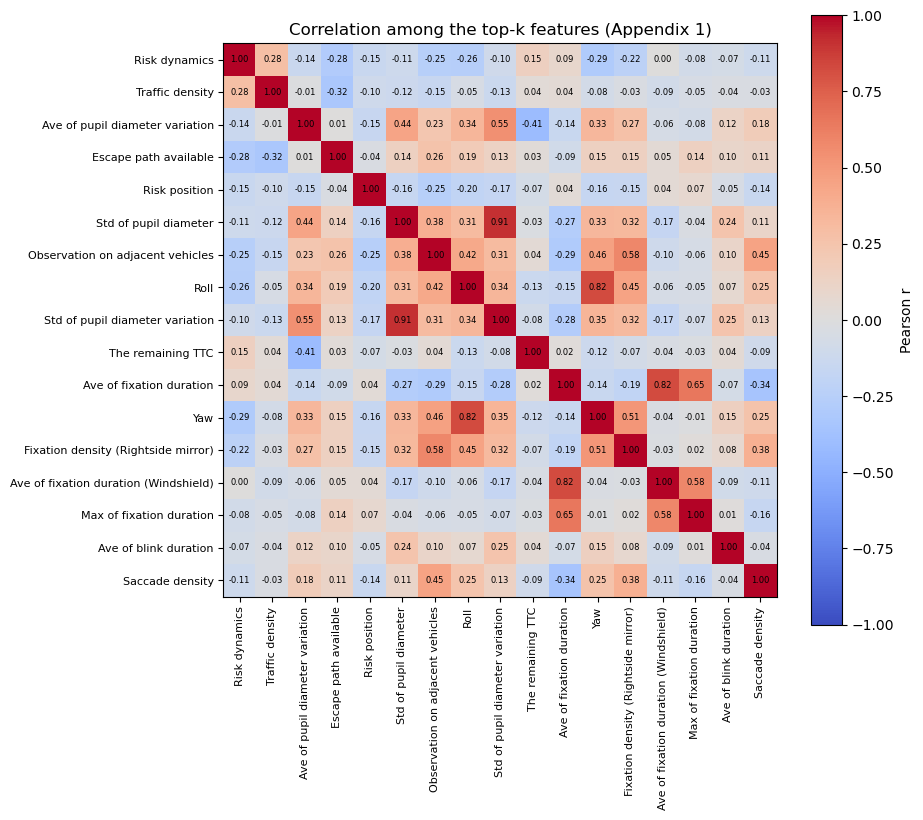

In [15]:
import matplotlib.pyplot as plt

CORR_THRESHOLD = 0.7
topk_features = list(selected_features)          # from Stage 2, ordered by SHAP importance
corr = X[topk_features].corr()                   # Pearson correlation among the top-k features

n = len(topk_features)
fig, ax = plt.subplots(figsize=(max(6, 0.55*n), max(5, 0.55*n)))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(topk_features, rotation=90, fontsize=8)
ax.set_yticks(range(n)); ax.set_yticklabels(topk_features, fontsize=8)
if n <= 20:
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center",
                    fontsize=6, color="black")
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
ax.set_title("Correlation among the top-k features (Appendix 1)")
plt.tight_layout(); plt.show()

In [16]:
# Remove the lower-importance feature of any pair with |r| > CORR_THRESHOLD.
# top_k is already ordered from most to least important, so processing in that order and dropping
# a feature whenever it correlates with an already-kept (more important) one retains the stronger
# feature of each correlated pair.
abscorr = corr.abs()
kept, dropped = [], []
for f in topk_features:
    if any(abscorr.loc[f, g] > CORR_THRESHOLD for g in kept):
        dropped.append(f)
    else:
        kept.append(f)

final_features = kept
print(f"top-k: {len(topk_features)}  ->  retained after |r| > {CORR_THRESHOLD} removal: {len(final_features)}")
print("removed:", dropped)
print("final features:", final_features)

top-k: 17  ->  retained after |r| > 0.7 removal: 14
removed: ['Std of pupil diameter variation', 'Yaw', 'Ave of fixation duration (Windshield)']
final features: ['Risk dynamics', 'Traffic density', 'Ave of pupil diameter variation', 'Escape path available', 'Risk position', 'Std of pupil diameter', 'Observation on adjacent vehicles', 'Roll', 'The remaining TTC', 'Ave of fixation duration', 'Fixation density (Rightside mirror)', 'Max of fixation duration', 'Ave of blink duration', 'Saccade density']


In [17]:
def cv_metrics(algo, X_sub, y, params, splits=10, seed=SEED, pos_label=POS_LABEL):
    cv = StratifiedKFold(n_splits=splits, shuffle=True, random_state=seed)
    acc, prec, rec, f1 = [], [], [], []
    for tr, te in cv.split(X_sub, y):
        est = make_estimator(algo, seed=seed, params=params).fit(X_sub.iloc[tr], y.iloc[tr])
        pred = est.predict(X_sub.iloc[te])
        acc.append(accuracy_score(y.iloc[te], pred))
        prec.append(precision_score(y.iloc[te], pred, pos_label=pos_label, zero_division=0))
        rec.append(recall_score(y.iloc[te], pred, pos_label=pos_label, zero_division=0))
        f1.append(f1_score(y.iloc[te], pred, pos_label=pos_label, zero_division=0))
    return dict(Accuracy=np.mean(acc), Precision=np.mean(prec),
                Recall=np.mean(rec), F1=np.mean(f1))

topk   = list(final_features)                          # Stage-2 top-k after pruning
env_in = [c for c in topk if _norm(c) in _env_norm]
eye_in = [c for c in topk if _norm(c) in _eye_norm]
all_in = [c for c in topk if c in env_in or c in eye_in]   # All = Environment union Eye-tracking
uncat  = [c for c in topk if c not in env_in and c not in eye_in]
if uncat:
    print("note: top-k features left out of the category split (excluded from All):", uncat)

feature_sets = {"All": all_in, "Environment": env_in, "Eye-tracking": eye_in}
rows = []
for name, feats in feature_sets.items():
    if len(feats) == 0:
        print(f"skip {name}: no features"); continue
    m = cv_metrics(ALGO_FOR_K, X[feats], y, params_k, splits=10)
    rows.append({"Feature set": name, "n_features": len(feats),
                 "Accuracy": f"{m['Accuracy']*100:.2f}%", "Precision": f"{m['Precision']*100:.2f}%",
                 "Recall": f"{m['Recall']*100:.2f}%", "F1": f"{m['F1']*100:.2f}%"})

table6 = pd.DataFrame(rows)
table6

,Feature set,n_features,Accuracy,Precision,Recall,F1
0,All,14,89.95%,80.52%,83.00%,81.38%
1,Environment,5,88.39%,80.81%,76.33%,77.72%
2,Eye-tracking,9,79.95%,63.43%,69.33%,65.57%
